In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [43]:
# FIXED loading
test_probs = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase4/Notebook/phase4_outputs/test_probs.npy")
test_preds = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase4/Notebook/phase4_outputs/test_preds.npy")

y_test = np.load("/Users/amarachi/Documents/AQA/Exp_3/phase3/notebook /phase3_features/y_test.npy")

test_df = pd.read_csv("/Users/amarachi/Documents/AQA/Exp_3/phase2/Notebook/strict_splits/test.csv")

print("Loaded correctly")
print("Sample probs:", test_probs[:5])

Loaded correctly
Sample probs: [0.99075407 0.98122066 0.87125604 0.84208937 0.99558499]


Min prob: 0.27898462766798543
Max prob: 1.0
Unique (rounded): [0.28 0.29 0.32 0.34 0.37 0.38 0.39 0.42 0.43 0.44 0.45 0.46 0.49 0.5
 0.51 0.52 0.53 0.54 0.56 0.57]


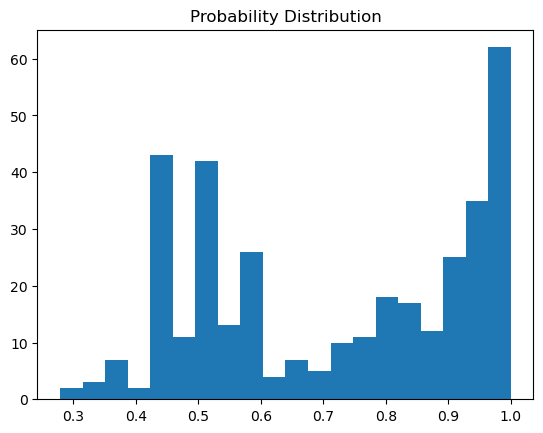

In [44]:
# VERIFY PROBABILITIES
print("Min prob:", np.min(test_probs))
print("Max prob:", np.max(test_probs))

print("Unique (rounded):", np.unique(np.round(test_probs, 2))[:20])

plt.hist(test_probs, bins=20)
plt.title("Probability Distribution")
plt.show()

In [45]:
#  BASELINE METRICS
# default threshold = 0.5
baseline_preds = (test_probs >= 0.5).astype(int)

precision = precision_score(y_test, baseline_preds)
recall = recall_score(y_test, baseline_preds)
f1 = f1_score(y_test, baseline_preds)
auc = roc_auc_score(y_test, test_probs)

print("\n=== BASELINE PERFORMANCE ===")
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("AUC:", auc)


=== BASELINE PERFORMANCE ===
Precision: 0.7097902097902098
Recall: 0.9022222222222223
F1: 0.7945205479452054
AUC: 0.8266153846153846



Brier Score: 0.1640650723321786
ECE: 0.1357816392932256


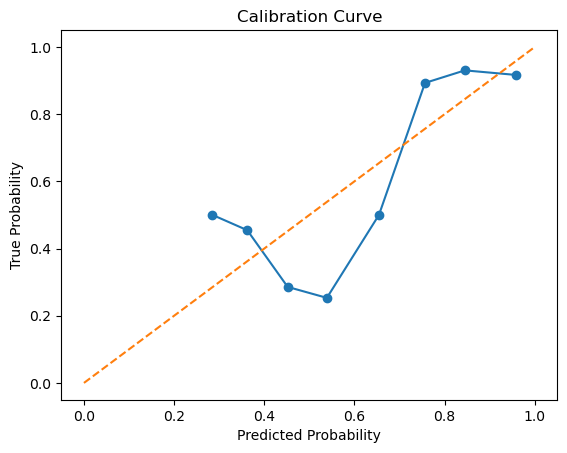

In [46]:
#CALIBRATION (Brier + ECE)
# Brier Score
brier = brier_score_loss(y_test, test_probs)
print("\nBrier Score:", brier)

# ECE
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(y_prob)
    
    return ece

ece = compute_ece(y_test, test_probs)
print("ECE:", ece)

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()

In [47]:
#BOOTSTRAP CONFIDENCE INTERVALS
def bootstrap_metric(y_true, y_pred, metric_fn, n=1000):
    scores = []
    n_samples = len(y_true)
    
    for _ in range(n):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_t = y_true[indices]
        y_p = y_pred[indices]
        scores.append(metric_fn(y_t, y_p))
    
    return np.percentile(scores, [2.5, 97.5])

ci_f1 = bootstrap_metric(y_test, baseline_preds, f1_score)
ci_precision = bootstrap_metric(y_test, baseline_preds, precision_score)
ci_recall = bootstrap_metric(y_test, baseline_preds, recall_score)

print("\n=== CONFIDENCE INTERVALS ===")
print("F1 CI:", ci_f1)
print("Precision CI:", ci_precision)
print("Recall CI:", ci_recall)


=== CONFIDENCE INTERVALS ===
F1 CI: [0.75362171 0.83206178]
Precision CI: [0.6539492  0.76140351]
Recall CI: [0.86265692 0.9409224 ]


In [48]:
# RISK-SENSITIVE EXPERIMENTs

cost_settings = [
    (1,1),
]

print("\n=== RISK-SENSITIVE RESULTS ===")

for C_fp, C_fn in cost_settings:
    tau = C_fp / (C_fp + C_fn)
    
    preds = (test_probs >= tau).astype(int)
    
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    
    print(f"\nCost FP={C_fp}, FN={C_fn}")
    print("Threshold:", round(tau,3))
    print("Precision:", round(p,4))
    print("Recall:", round(r,4))
    print("F1:", round(f,4))


=== RISK-SENSITIVE RESULTS ===

Cost FP=1, FN=1
Threshold: 0.5
Precision: 0.7098
Recall: 0.9022
F1: 0.7945


In [49]:
# RISK-SENSITIVE EXPERIMENT

cost_settings = [
    (1,3)
]

print("\n=== RISK-SENSITIVE RESULTS ===")

for C_fp, C_fn in cost_settings:
    tau = C_fp / (C_fp + C_fn)
    
    preds = (test_probs >= tau).astype(int)
    
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    
    print(f"\nCost FP={C_fp}, FN={C_fn}")
    print("Threshold:", round(tau,3))
    print("Precision:", round(p,4))
    print("Recall:", round(r,4))
    print("F1:", round(f,4))


=== RISK-SENSITIVE RESULTS ===

Cost FP=1, FN=3
Threshold: 0.25
Precision: 0.6338
Recall: 0.973
F1: 0.7759


In [50]:
# RISK-SENSITIVE EXPERIMENT

cost_settings = [
    (1,5)
]

print("\n=== RISK-SENSITIVE RESULTS ===")

for C_fp, C_fn in cost_settings:
    tau = C_fp / (C_fp + C_fn)
    
    preds = (test_probs >= tau).astype(int)
    
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds)
    
    print(f"\nCost FP={C_fp}, FN={C_fn}")
    print("Threshold:", round(tau,3))
    print("Precision:", round(p,4))
    print("Recall:", round(r,4))
    print("F1:", round(f,4))


=== RISK-SENSITIVE RESULTS ===

Cost FP=1, FN=5
Threshold: 0.167
Precision: 0.6338
Recall: 0.998
F1: 0.7759


In [51]:
# ERROR ANALYSIS
errors = test_df.copy()
errors["label"] = y_test
errors["pred"] = baseline_preds
errors["prob"] = test_probs

false_negatives = errors[(errors["label"]==1) & (errors["pred"]==0)]
false_positives = errors[(errors["label"]==0) & (errors["pred"]==1)]

print("\n=== ERROR ANALYSIS ===")
print("False Negatives:", len(false_negatives))
print("False Positives:", len(false_positives))

print("\nSample FN:")
print(false_negatives["text"].head(5))

print("\nSample FP:")
print(false_positives["text"].head(5))


=== ERROR ANALYSIS ===
False Negatives: 22
False Positives: 83

Sample FN:
124    the system shall be able to handle 1000 custom...
125    the system shall be able to retrieve 200 produ...
126    the system shall be able to add product to sho...
127    the system shall be able to search for a speci...
129    the system shall be able to validate credit ca...
Name: text, dtype: object

Sample FP:
2      registration citizens can register their compl...
3      citizens can register their complaints with po...
114    shall install online help for users via the we...
115    shall deliver operations and maintenance manua...
136    the system shall auto detect ip dos attacks an...
Name: text, dtype: object
